# DATA ANALYSIS - Data Type Profiler

End-to-end notebook covering:
1. Load & merge feature data
2. Null value handling
3. Data distributions (labels, characters, lengths, entropy)
4. Correlation matrix
5. PCA on word embeddings
6. Embedding model (FastText OOV handling)
7. Visualizations (neighbors, clustering, score distributions)

## 0. Imports

In [1]:
import re
import random
from typing import Dict, List

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.manifold import TSNE
from sklearn.feature_extraction.text import TfidfVectorizer

from gensim.models import KeyedVectors

import warnings
warnings.filterwarnings('ignore')

Provide paths to CSV files generated by the data pipeline which contains the extracted data

In [2]:
files= [
    'data/features_viznet_train_auto_labeled_subset.csv',
    'data/features_non_viznet_auto_labeled.csv',
    'data/features_gittables_auto_labeled.csv'
]

## 1. Load Data

In [3]:
def load_features(filepath: str) -> pd.DataFrame:
    df = pd.read_csv(filepath)
    print(f"  Loaded {filepath}: {df.shape}")
    return df


def load_and_merge_features(filepaths: List[str]) -> pd.DataFrame:
    dfs = [load_features(fp) for fp in filepaths]
    merged = pd.concat(dfs, ignore_index=True)
    print(f"\nMerged dataset shape: {merged.shape}")
    return merged


FT_features = load_and_merge_features(files)

  Loaded data/features_viznet_train_auto_labeled_subset.csv: (200, 2508)
  Loaded data/features_non_viznet_auto_labeled.csv: (1396, 2508)
  Loaded data/features_gittables_auto_labeled.csv: (1856, 2508)

Merged dataset shape: (3452, 2508)


## 2. Handle Null Values

In [4]:
def check_nulls(df: pd.DataFrame) -> None:
    null_cols = {col: df[col].isnull().sum() for col in df.columns if df[col].isnull().sum() > 0}
    if null_cols:
        for col, count in null_cols.items():
            print(f"  {col}: {count} nulls")
    else:
        print("  No null values found.")

check_nulls(FT_features)

  skew_length: 1207 nulls
  kurtosis_length: 1207 nulls


In [5]:
FT_features['skew_length'].fillna(0.0, inplace=True)
FT_features['kurtosis_length'].fillna(-3.0, inplace=True)
print("Nulls after fill:")
check_nulls(FT_features)

Nulls after fill:
  No null values found.


## 3. Data Distributions

### 3.1 Data Type Column

Unique DataTypes: 6

Data type distribution:
DataType
varchar      1560
number       1435
boolean       210
date          172
timestamp      73
time            2
Name: count, dtype: int64


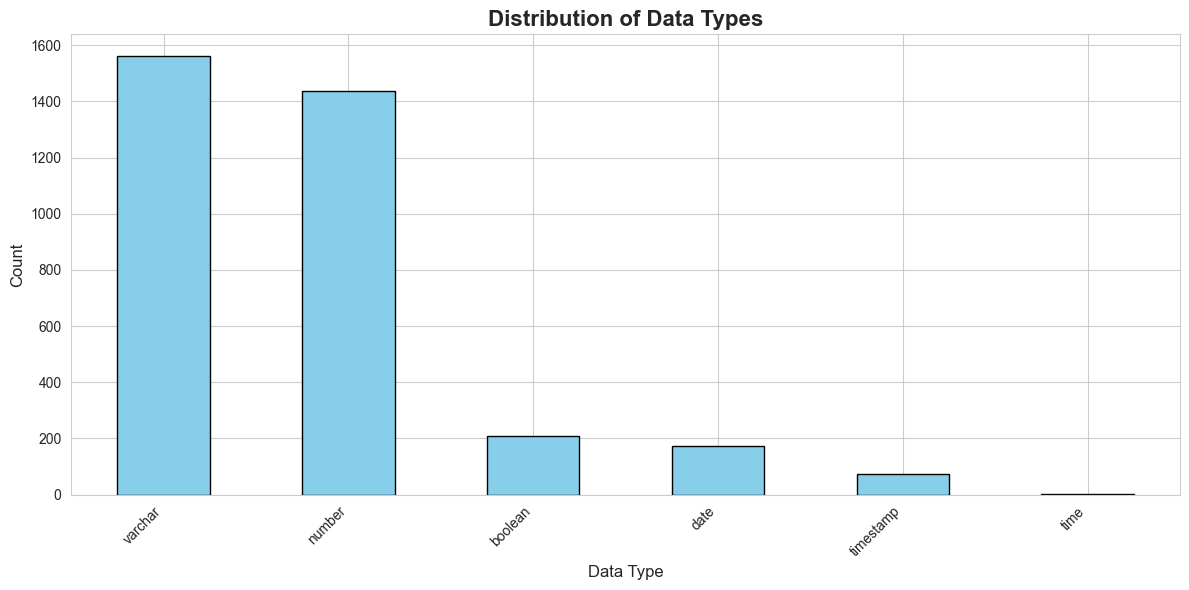


Max num_of_segments: 7


In [6]:
def plot_label_column(df: pd.DataFrame) -> None:
    print(f"Unique DataTypes: {df['DataType'].nunique()}")
    datatype_counts = df['DataType'].value_counts()
    print("\nData type distribution:")
    print(datatype_counts)

    plt.figure(figsize=(12, 6))
    datatype_counts.plot(kind='bar', color='skyblue', edgecolor='black')
    plt.title('Distribution of Data Types', fontsize=16, fontweight='bold')
    plt.xlabel('Data Type', fontsize=12)
    plt.ylabel('Count', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

plot_label_column(FT_features)
print("\nMax num_of_segments:", max(FT_features['num_of_segments']))

### 3.2 Character Distribution Columns


Top 10 most frequent characters:
0    0.166954
1    0.080633
2    0.069044
.    0.045464
3    0.044320
5    0.041474
4    0.041242
e    0.033893
6    0.033783
9    0.032558
dtype: float64


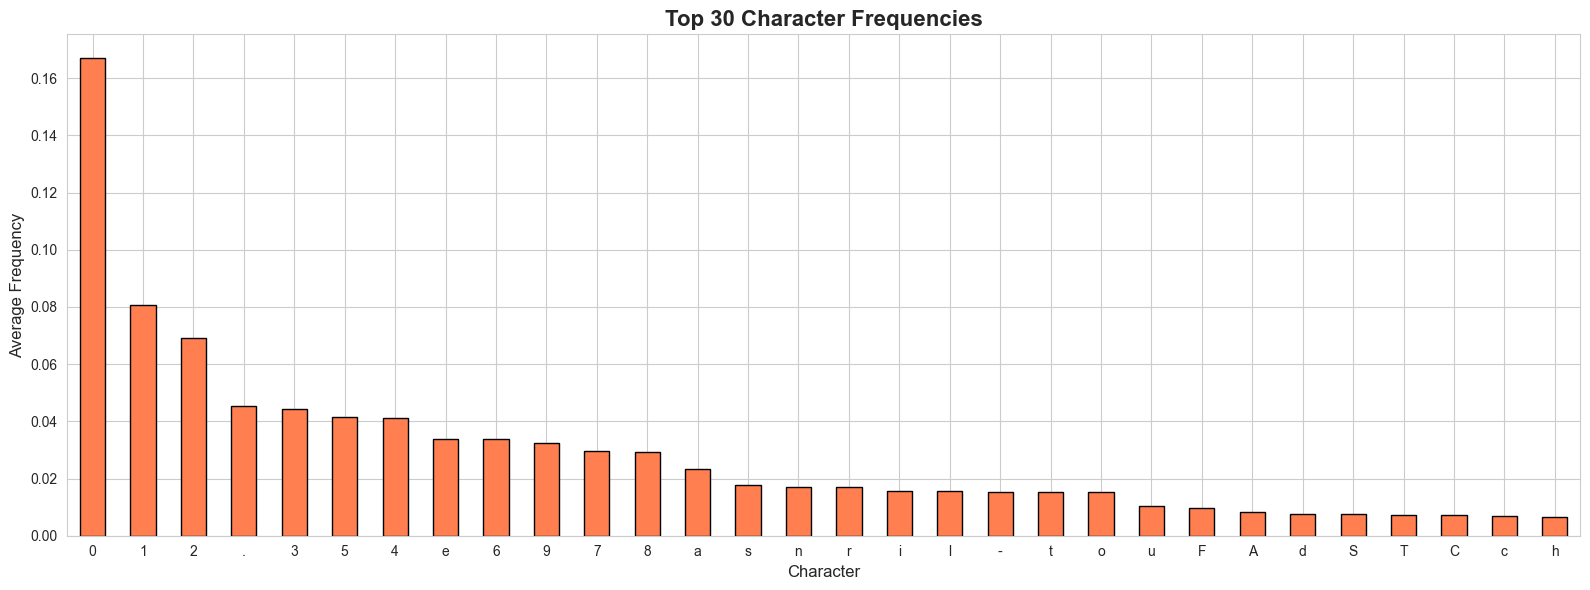

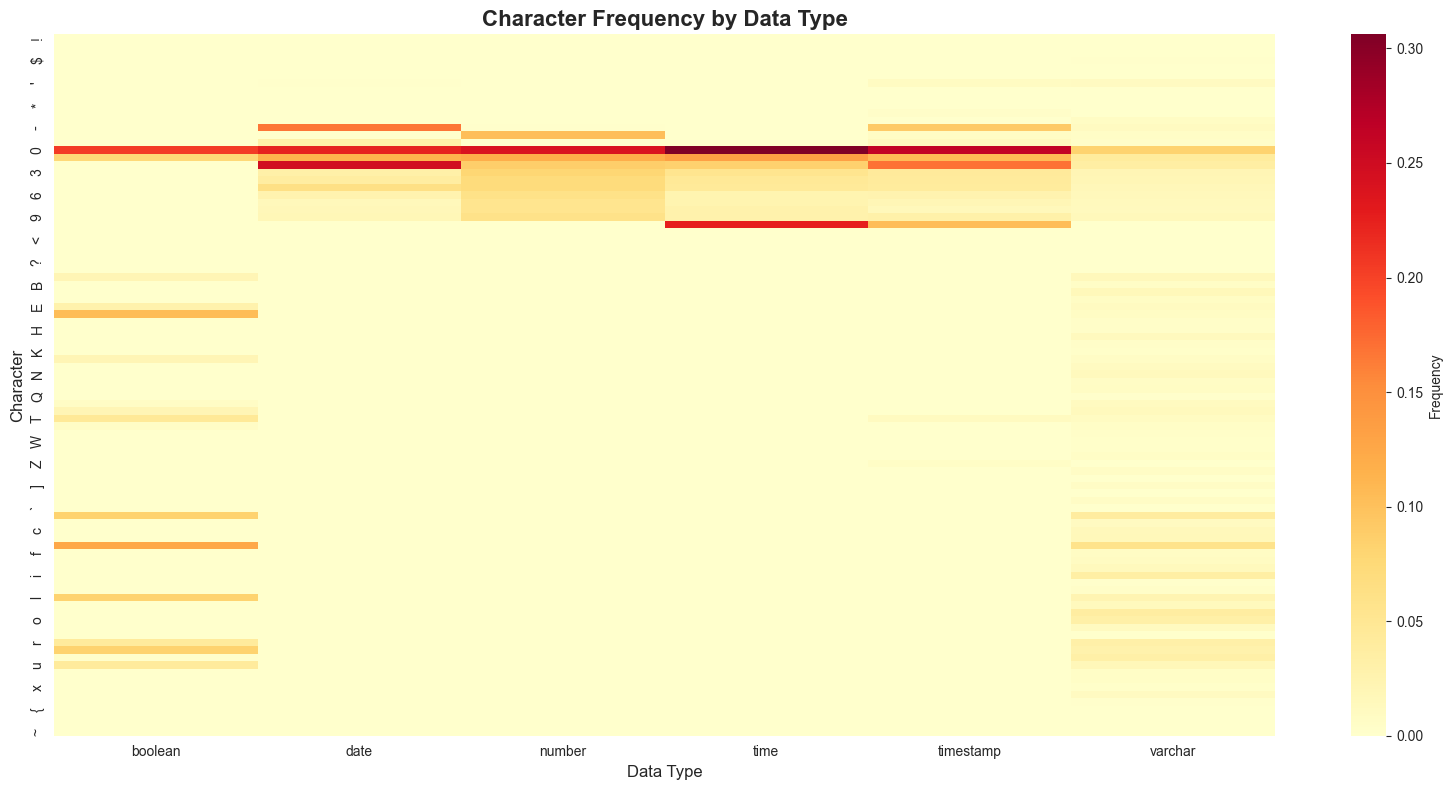

In [7]:
char_columns = [chr(i) for i in range(33, 127)]


def plot_character_dist(df: pd.DataFrame) -> None:
    char_stats = df[char_columns].mean().sort_values(ascending=False)
    print("\nTop 10 most frequent characters:")
    print(char_stats.head(10))

    plt.figure(figsize=(16, 6))
    char_stats.head(30).plot(kind='bar', color='coral', edgecolor='black')
    plt.title('Top 30 Character Frequencies', fontsize=16, fontweight='bold')
    plt.xlabel('Character', fontsize=12)
    plt.ylabel('Average Frequency', fontsize=12)
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()


def plot_char_dist_group_by_label(df: pd.DataFrame) -> None:
    plt.figure(figsize=(16, 8))
    char_by_type = df.groupby('DataType')[char_columns].mean()
    sns.heatmap(char_by_type.T, cmap='YlOrRd', cbar_kws={'label': 'Frequency'})
    plt.title('Character Frequency by Data Type', fontsize=16, fontweight='bold')
    plt.xlabel('Data Type', fontsize=12)
    plt.ylabel('Character', fontsize=12)
    plt.tight_layout()
    plt.show()


plot_character_dist(FT_features)
plot_char_dist_group_by_label(FT_features)

### 3.3 Length Statistics Columns

        min_length   max_length  mean_length  median_length  skew_length  \
count  3452.000000  3452.000000  3452.000000    3452.000000  3452.000000   
mean      8.037949    22.770857    12.413046      11.928882     3.040834   
std      10.000928   126.147308    26.311117      22.732095    59.101960   
min       1.000000     1.000000     1.000000       1.000000  -174.975713   
25%       2.000000     4.000000     3.500000       3.000000    -0.629440   
50%       4.000000    10.000000     8.000000       8.000000     0.000000   
75%      10.000000    18.000000    16.599992      16.000000     0.323560   
max     200.000000  3988.000000   815.285714     723.500000  1503.541153   

       kurtosis_length  
count     3.452000e+03  
mean      3.502661e+03  
std       8.178128e+04  
min      -3.000000e+00  
25%      -3.000000e+00  
50%       2.125573e+00  
75%       4.745277e+00  
max       2.260637e+06  


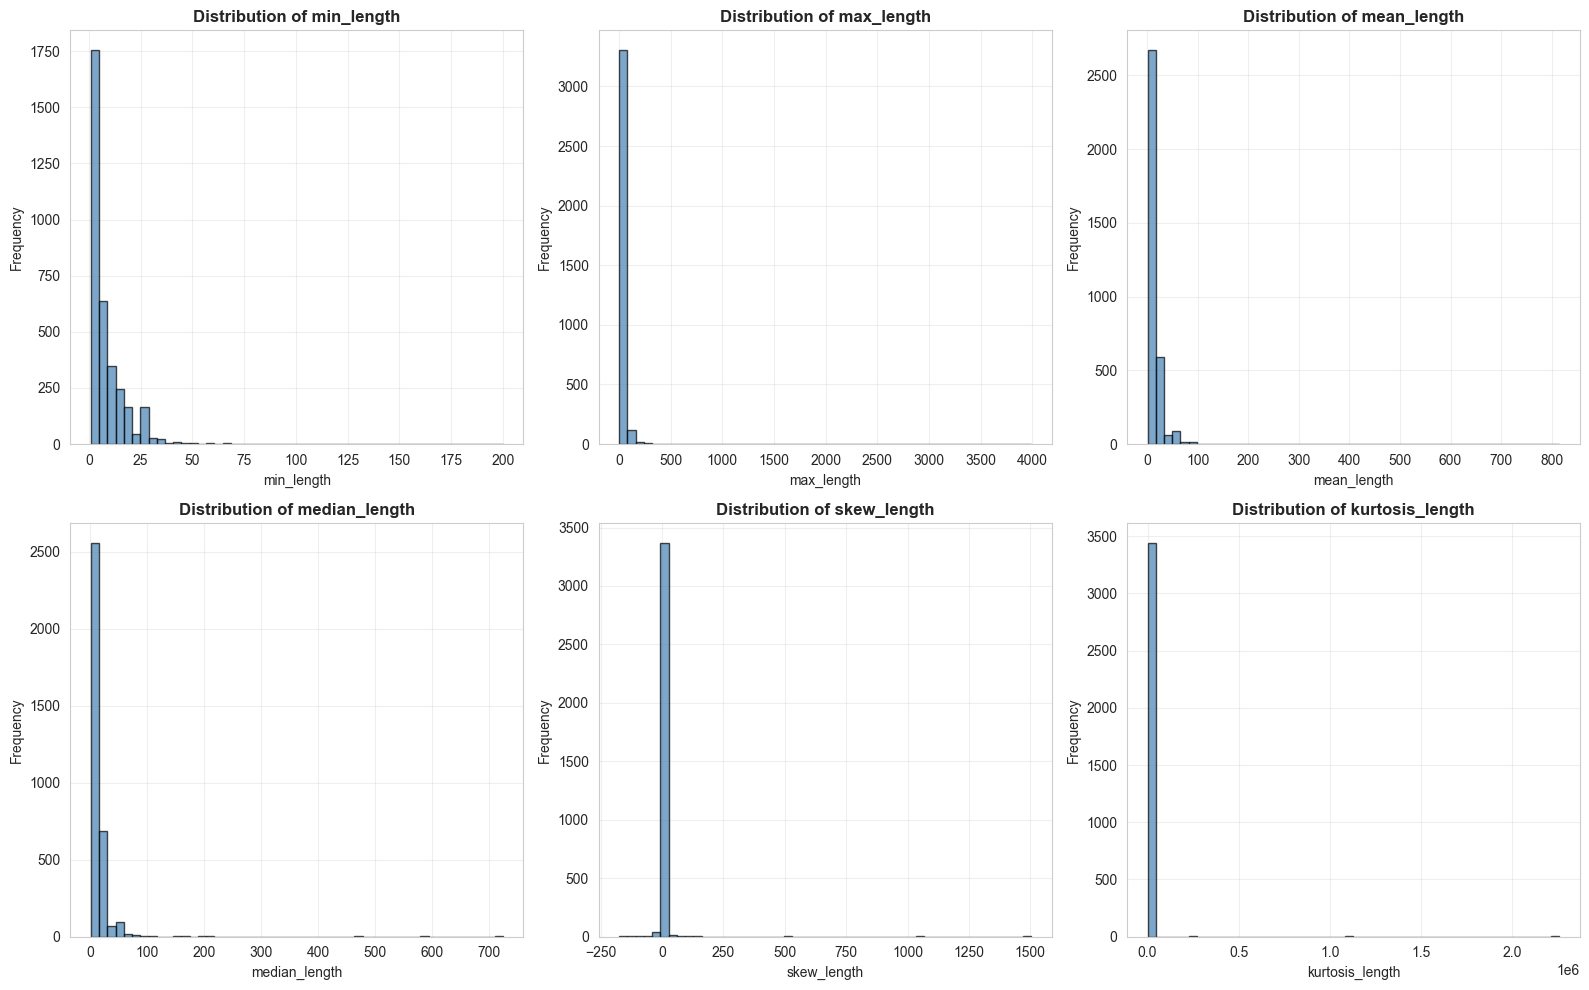

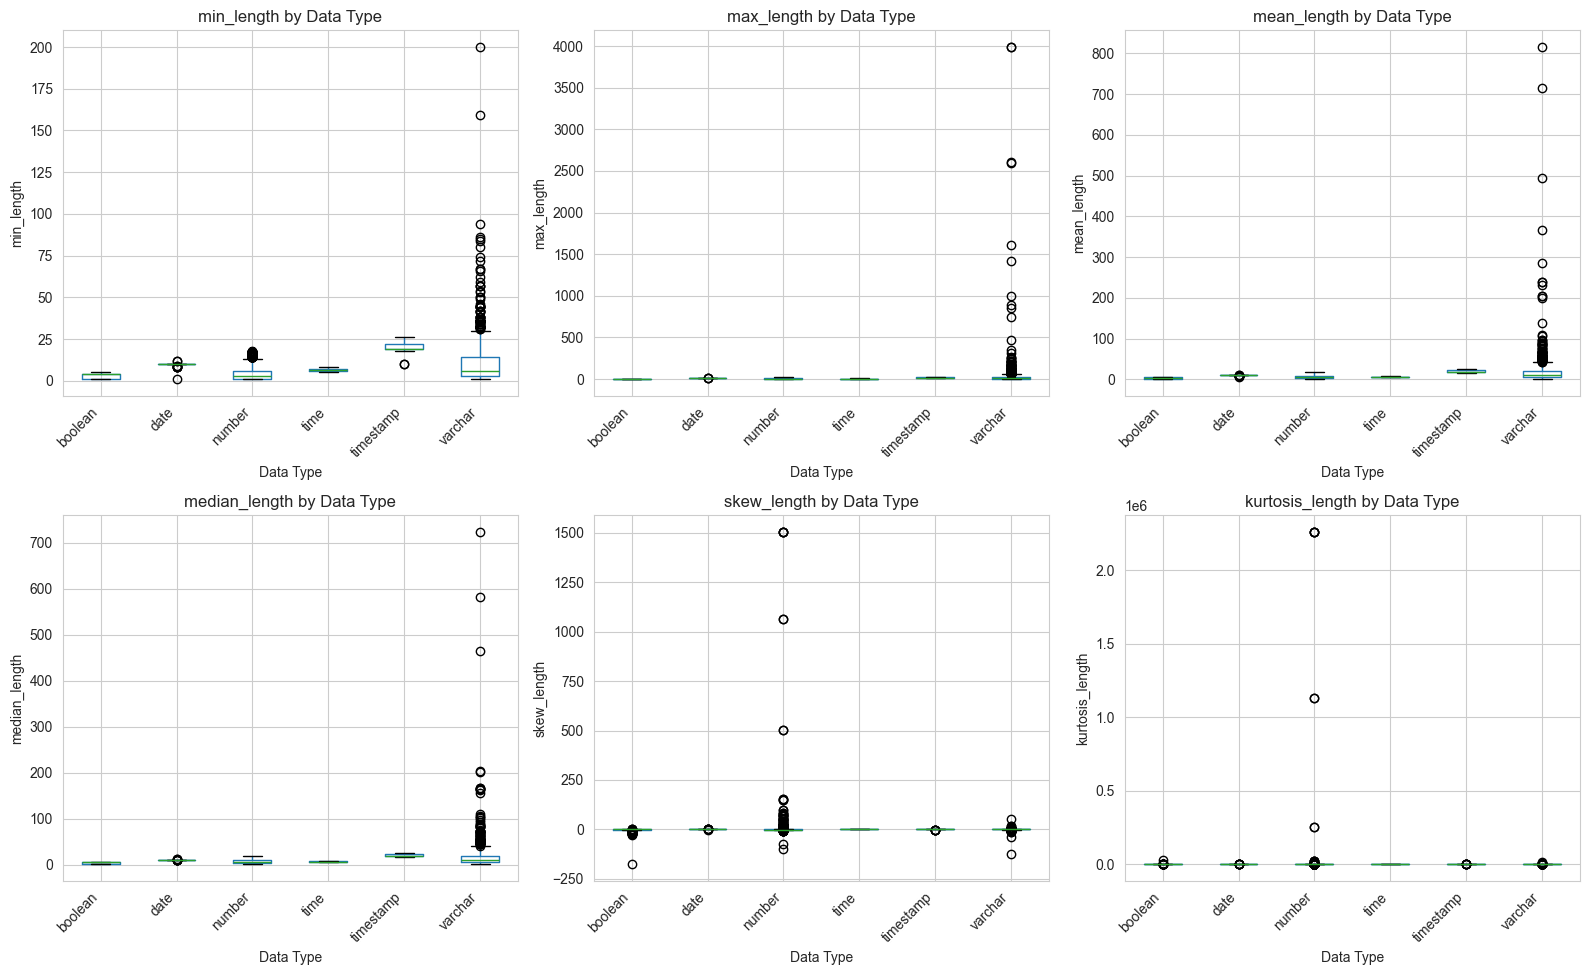

In [8]:
length_columns = ['min_length', 'max_length', 'mean_length', 'median_length',
                  'skew_length', 'kurtosis_length']


def plot_length_distribution(df: pd.DataFrame) -> None:
    print(df[length_columns].describe())

    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    axes = axes.ravel()
    for idx, col in enumerate(length_columns):
        axes[idx].hist(df[col].dropna(), bins=50, color='steelblue', edgecolor='black', alpha=0.7)
        axes[idx].set_title(f'Distribution of {col}', fontweight='bold')
        axes[idx].set_xlabel(col)
        axes[idx].set_ylabel('Frequency')
        axes[idx].grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_length_distribution_group_by_label(df: pd.DataFrame) -> None:
    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    axes = axes.ravel()
    for idx, col in enumerate(length_columns):
        df.boxplot(column=col, by='DataType', ax=axes[idx])
        axes[idx].set_title(f'{col} by Data Type')
        axes[idx].set_xlabel('Data Type')
        axes[idx].set_ylabel(col)
        plt.sca(axes[idx])
        plt.xticks(rotation=45, ha='right')
    plt.suptitle('')
    plt.tight_layout()
    plt.show()


plot_length_distribution(FT_features)
plot_length_distribution_group_by_label(FT_features)

### 3.4 Entropy Column

count    3452.000000
mean        4.405183
std         4.093951
min         0.000000
25%         0.996992
50%         3.565833
75%         7.093297
max        23.665564
Name: entropy, dtype: float64


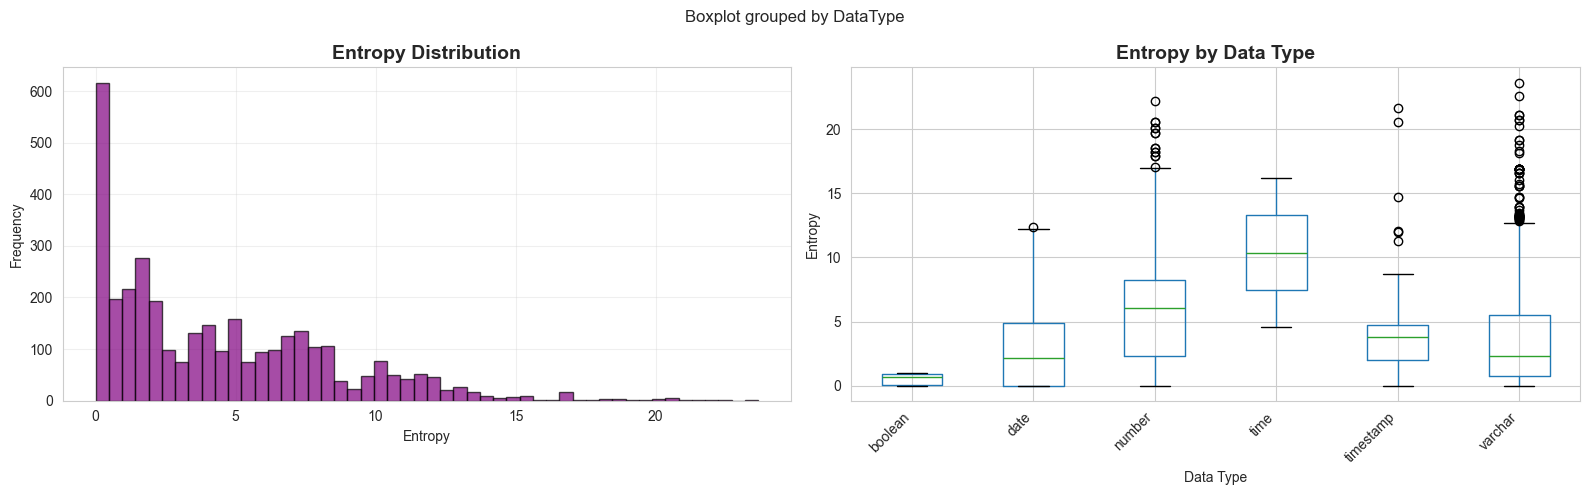

In [9]:
def plot_entropy_distribution(df: pd.DataFrame) -> None:
    print(df['entropy'].describe())

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    axes[0].hist(df['entropy'].dropna(), bins=50, color='purple', edgecolor='black', alpha=0.7)
    axes[0].set_title('Entropy Distribution', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Entropy')
    axes[0].set_ylabel('Frequency')
    axes[0].grid(True, alpha=0.3)

    df.boxplot(column='entropy', by='DataType', ax=axes[1])
    axes[1].set_title('Entropy by Data Type', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Data Type')
    axes[1].set_ylabel('Entropy')
    plt.sca(axes[1])
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

plot_entropy_distribution(FT_features)

## 4. Correlation Matrix

Calculating correlations for 103 non-embedding features...


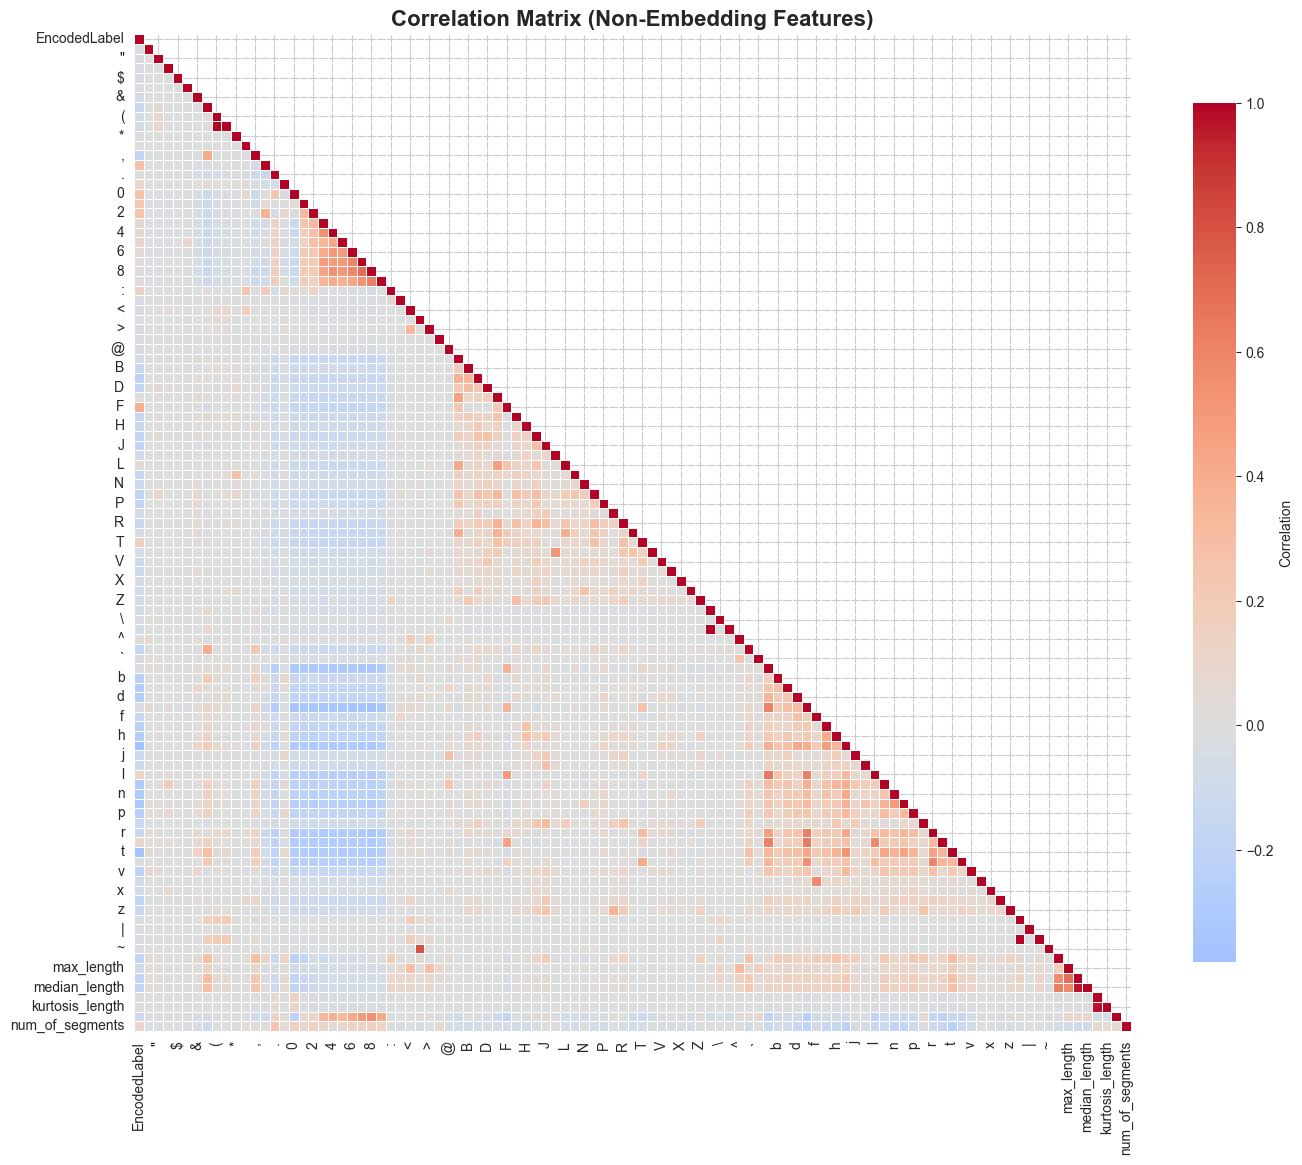


Highly correlated feature pairs (|correlation| > 0.8):
     Feature 1        Feature 2  Correlation
1            [                ]     1.000000
2            {                }     1.000000
0            (                )     0.999970
4  skew_length  kurtosis_length     0.972658
3  mean_length    median_length     0.960420


In [10]:
def plot_corr_matrix(df: pd.DataFrame) -> None:
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    non_embedding_cols = [col for col in numeric_cols if not col.startswith('emb_')]
    print(f"Calculating correlations for {len(non_embedding_cols)} non-embedding features...")

    corr_matrix = df[non_embedding_cols].corr()

    plt.figure(figsize=(14, 12))
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
    sns.heatmap(corr_matrix, mask=mask, annot=False, cmap='coolwarm',
                center=0, square=True, linewidths=0.5,
                cbar_kws={"shrink": 0.8, "label": "Correlation"})
    plt.title('Correlation Matrix (Non-Embedding Features)', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

    print("\nHighly correlated feature pairs (|correlation| > 0.8):")
    high_corr = [
        {'Feature 1': corr_matrix.columns[i],
         'Feature 2': corr_matrix.columns[j],
         'Correlation': corr_matrix.iloc[i, j]}
        for i in range(len(corr_matrix.columns))
        for j in range(i + 1, len(corr_matrix.columns))
        if abs(corr_matrix.iloc[i, j]) > 0.8
    ]
    if high_corr:
        print(pd.DataFrame(high_corr).sort_values('Correlation', ascending=False).head(20))
    else:
        print("No highly correlated pairs found.")

plot_corr_matrix(FT_features)

## 5. PCA on Word Embeddings

Explained variance ratio (first 30 PCs):
  PC1: 0.1429 (14.29%)
  PC2: 0.0911 (9.11%)
  PC3: 0.0572 (5.72%)
  PC4: 0.0425 (4.25%)
  PC5: 0.0314 (3.14%)
  PC6: 0.0244 (2.44%)
  PC7: 0.0218 (2.18%)
  PC8: 0.0183 (1.83%)
  PC9: 0.0170 (1.70%)
  PC10: 0.0164 (1.64%)
  PC11: 0.0158 (1.58%)
  PC12: 0.0149 (1.49%)
  PC13: 0.0142 (1.42%)
  PC14: 0.0132 (1.32%)
  PC15: 0.0125 (1.25%)
  PC16: 0.0119 (1.19%)
  PC17: 0.0111 (1.11%)
  PC18: 0.0110 (1.10%)
  PC19: 0.0105 (1.05%)
  PC20: 0.0097 (0.97%)
  PC21: 0.0094 (0.94%)
  PC22: 0.0090 (0.90%)
  PC23: 0.0083 (0.83%)
  PC24: 0.0082 (0.82%)
  PC25: 0.0081 (0.81%)
  PC26: 0.0079 (0.79%)
  PC27: 0.0075 (0.75%)
  PC28: 0.0072 (0.72%)
  PC29: 0.0070 (0.70%)
  PC30: 0.0067 (0.67%)
  Cumulative (first 25): 0.6307


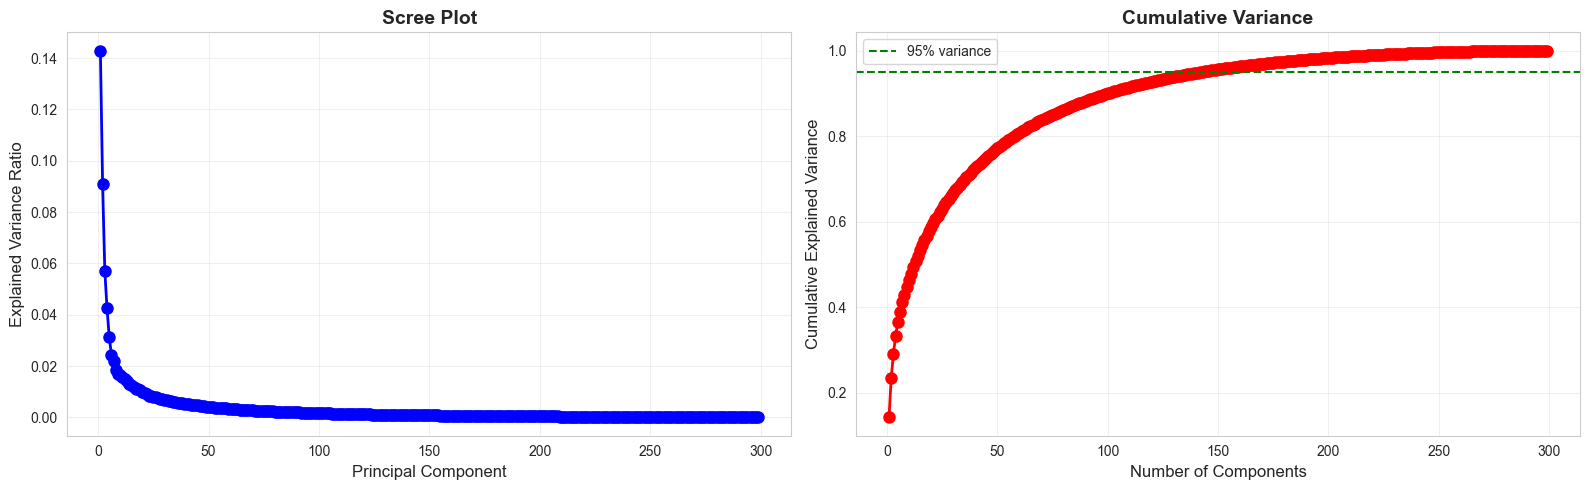

In [11]:
def embeddings_pca(df: pd.DataFrame) -> None:
    embedding_prefixes = [f'emb_w{i}_' for i in range(1, 9)]

    all_emb_data = None
    for prefix in embedding_prefixes:
        emb_cols = [col for col in df.columns if col.startswith(prefix)]
        emb_data = df[emb_cols].values.tolist()
        all_emb_data = emb_data if all_emb_data is None else all_emb_data + emb_data

    all_emb_data = np.array(all_emb_data)
    all_emb_df = pd.DataFrame(all_emb_data, columns=[f'emb_{i}' for i in range(all_emb_data.shape[1])]).dropna()

    scaler = StandardScaler()
    scaler.set_output(transform='pandas')
    scaled_data = scaler.fit_transform(all_emb_df)

    pca = PCA(n_components='mle')
    pca.fit_transform(scaled_data)

    print("Explained variance ratio (first 30 PCs):")
    for i, var in enumerate(pca.explained_variance_ratio_[:30], 1):
        print(f"  PC{i}: {var:.4f} ({var*100:.2f}%)")
    print(f"  Cumulative (first 25): {pca.explained_variance_ratio_[:25].sum():.4f}")

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    axes[0].plot(range(1, len(pca.explained_variance_ratio_) + 1),
                 pca.explained_variance_ratio_, 'bo-', linewidth=2, markersize=8)
    axes[0].set_xlabel('Principal Component', fontsize=12)
    axes[0].set_ylabel('Explained Variance Ratio', fontsize=12)
    axes[0].set_title('Scree Plot', fontsize=14, fontweight='bold')
    axes[0].grid(True, alpha=0.3)

    cumsum_var = np.cumsum(pca.explained_variance_ratio_)
    axes[1].plot(range(1, len(cumsum_var) + 1), cumsum_var, 'ro-', linewidth=2, markersize=8)
    axes[1].axhline(y=0.95, color='g', linestyle='--', label='95% variance')
    axes[1].set_xlabel('Number of Components', fontsize=12)
    axes[1].set_ylabel('Cumulative Explained Variance', fontsize=12)
    axes[1].set_title('Cumulative Variance', fontsize=14, fontweight='bold')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

embeddings_pca(FT_features)

## 6. Embedding Model (FastText)

In [12]:
class EmbeddingModel:
    """Wraps a Word2Vec/FastText KeyedVectors model with OOV handling via TF-IDF surface similarity."""

    def __init__(self, name: str, model_filepath: str, oov_results_filepath: str,
                 ngram_range: tuple = (3, 5)) -> None:
        self.name = name
        self.embedding_model = KeyedVectors.load_word2vec_format(model_filepath, binary=False)
        self.vocab = self.embedding_model.index_to_key
        self.vectorizer = TfidfVectorizer(analyzer='char', ngram_range=ngram_range)
        self.vocab_tfidf = self.vectorizer.fit_transform(self.vocab)
        self.oov_data = self._load_oov_results(oov_results_filepath)

    # ── Similarity & embedding helpers ────────────────────────────────────

    def surface_similarity_batch(self, word: str) -> np.ndarray:
        word_tfidf = self.vectorizer.transform([word])
        return cosine_similarity(word_tfidf, self.vocab_tfidf)[0]

    def get_nearest_neighbors(self, word: str, top_k: int = 5) -> list:
        similarities = self.surface_similarity_batch(word)
        top_k_indices = (
            np.argpartition(similarities, -top_k)[-top_k:]
            if top_k < len(similarities)
            else np.argsort(similarities)[::-1][:top_k]
        )
        top_k_indices = top_k_indices[np.argsort(similarities[top_k_indices])[::-1]]
        return [(self.vocab[idx], similarities[idx]) for idx in top_k_indices]

    def get_embedding(self, word: str, top_k: int = 5) -> np.ndarray:
        if self.embedding_model.has_index_for(word):
            return self.embedding_model[word]
        similarities = self.surface_similarity_batch(word)
        top_k_indices = (
            np.argpartition(similarities, -top_k)[-top_k:]
            if top_k < len(similarities)
            else np.argsort(similarities)[::-1][:top_k]
        )
        top_k_indices = top_k_indices[np.argsort(similarities[top_k_indices])[::-1]]
        weights = similarities[top_k_indices] / (similarities[top_k_indices].sum() + 1e-10)
        vectors = np.array([self.embedding_model[self.vocab[idx]] for idx in top_k_indices])
        return weights @ vectors

    # ── OOV loader ─────────────────────────────────────────────────────────

    def _load_oov_results(self, filepath: str) -> dict:
        df = pd.read_csv(filepath).drop_duplicates()
        oov_dict = {}
        pattern = r"\('([^']+)',\s*(?:np\.float64\()?([0-9.]+)\)?\)"
        for _, row in df.iterrows():
            oov_word = row['OOV']
            if pd.isna(oov_word) or str(oov_word).strip() == '':
                continue
            try:
                matches = re.findall(pattern, str(row['Best_Candidates']).strip())
                candidates = [(w, float(s)) for w, s in matches]
                if candidates:
                    oov_dict[oov_word] = candidates
            except Exception as e:
                print(f"Warning: Could not parse candidates for '{oov_word}': {e}")
        return oov_dict

In [13]:
FT_model = EmbeddingModel(
    name='FastText',
    model_filepath='model/crawl-300d-2M-subword.vec',
    oov_results_filepath='data/oov_results_fast_text.csv',
)
print(f"{FT_model.name}: {len(FT_model.oov_data)} OOV words loaded")

FastText: 41 OOV words loaded


## 7. Embedding Visualizations

### 7.1 Nearest Neighbors

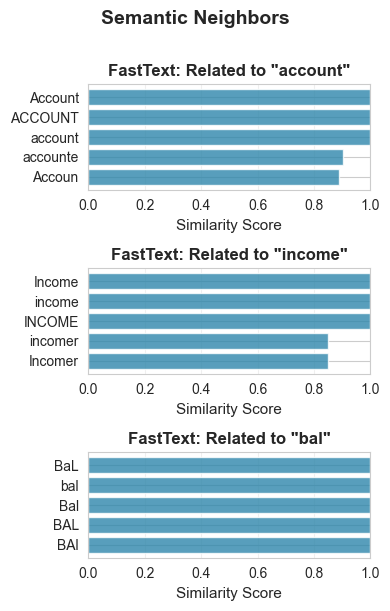

In [14]:
def plot_neighbor_comparison(model: EmbeddingModel, terms: List[str], k: int = 10) -> None:
    fig, axes = plt.subplots(len(terms), 1, figsize=(4, 2 * len(terms)))
    axes = np.array(axes).reshape(-1)

    for i, term in enumerate(terms):
        neighbors = model.get_nearest_neighbors(term, top_k=k)
        if not neighbors:
            continue
        words, sims = zip(*neighbors)
        axes[i].barh(range(len(words)), sims, color='#2E86AB', alpha=0.8)
        axes[i].set_yticks(range(len(words)))
        axes[i].set_yticklabels(words, fontsize=10)
        axes[i].set_xlabel('Similarity Score', fontsize=11)
        axes[i].set_title(f'{model.name}: Related to "{term}"', fontsize=12, fontweight='bold')
        axes[i].invert_yaxis()
        axes[i].grid(axis='x', alpha=0.3)
        axes[i].set_xlim(0, 1)

    plt.suptitle('Semantic Neighbors', fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()

plot_neighbor_comparison(FT_model, ['account', 'income', 'bal'], k=5)

### 7.2 OOV Candidate Comparison

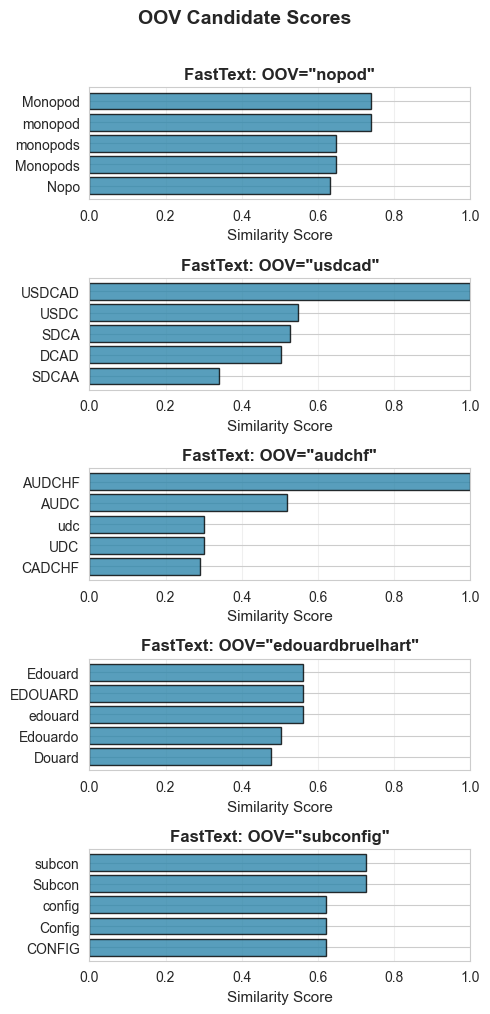

In [15]:
def plot_candidate_comparison(model: EmbeddingModel, n_words: int = 5) -> None:
    oov_words = random.sample(list(model.oov_data.keys()), k=min(n_words, len(model.oov_data)))
    if not oov_words:
        print("No OOV words available.")
        return

    fig, axes = plt.subplots(len(oov_words), 1, figsize=(5, 2 * len(oov_words)))
    axes = np.array(axes).reshape(-1)

    for i, oov_word in enumerate(oov_words):
        cands = model.oov_data.get(oov_word, [])
        if not cands:
            continue
        words, scores = zip(*cands)
        axes[i].barh(range(len(words)), scores, color='#2E86AB', alpha=0.8, edgecolor='black')
        axes[i].set_yticks(range(len(words)))
        axes[i].set_yticklabels(words, fontsize=10)
        axes[i].set_xlabel('Similarity Score', fontsize=11)
        axes[i].set_title(f'{model.name}: OOV="{oov_word}"', fontsize=12, fontweight='bold')
        axes[i].invert_yaxis()
        axes[i].grid(axis='x', alpha=0.3)
        axes[i].set_xlim(0, 1)

    plt.suptitle('OOV Candidate Scores', fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()

plot_candidate_comparison(FT_model)

### 7.3 t-SNE Sector Clustering

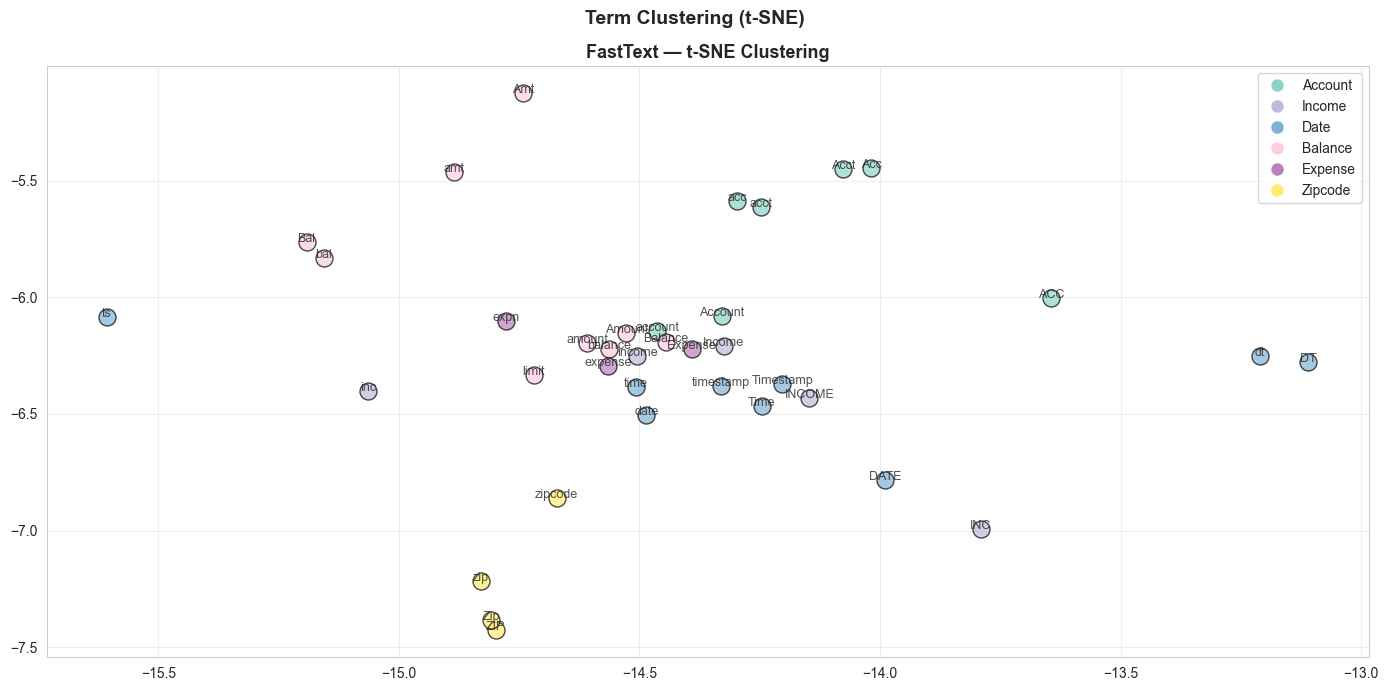

In [16]:
def plot_sector_clustering(model: EmbeddingModel, sector_terms: Dict[str, List[str]]) -> None:
    all_terms, sector_labels = [], []
    for sector, terms in sector_terms.items():
        all_terms.extend(terms)
        sector_labels.extend([sector] * len(terms))

    vecs = np.array([model.get_embedding(t, 5) for t in all_terms])
    perplexity = min(30, len(all_terms) - 1)
    vecs_2d = TSNE(n_components=2, random_state=42, perplexity=perplexity).fit_transform(vecs)

    colors = plt.cm.Set3(np.linspace(0, 1, len(sector_terms)))
    sector_to_color = {sector: colors[i] for i, sector in enumerate(sector_terms.keys())}

    fig, ax = plt.subplots(figsize=(14, 7))
    for j, (term, sector) in enumerate(zip(all_terms, sector_labels)):
        ax.scatter(vecs_2d[j, 0], vecs_2d[j, 1], c=[sector_to_color[sector]],
                   s=150, alpha=0.7, edgecolors='black', linewidth=1)
        ax.annotate(term, (vecs_2d[j, 0], vecs_2d[j, 1]), fontsize=9, alpha=0.8, ha='center')

    legend_elements = [
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=sector_to_color[s],
                   markersize=10, label=s)
        for s in sector_terms
    ]
    ax.legend(handles=legend_elements, loc='upper right', fontsize=10)
    ax.set_title(f'{model.name} — t-SNE Clustering', fontsize=13, fontweight='bold')
    ax.grid(True, alpha=0.3)
    plt.suptitle('Term Clustering (t-SNE)', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()


sector_terms = {
    'Account':  ['account', 'acc', 'acct', 'Account', 'ACC', 'Acct', 'Acc'],
    'Income':   ['inc', 'income', 'INC', 'INCOME', 'Income'],
    'Date':     ['date', 'dt', 'DATE', 'DT', 'Time', 'time', 'timestamp', 'ts', 'Timestamp'],
    'Balance':  ['bal', 'balance', 'Balance', 'Bal', 'Amount', 'Amt', 'amt', 'amount', 'limit'],
    'Expense':  ['expense', 'Expense', 'expn'],
    'Zipcode':  ['zip', 'ZIP', 'Zip', 'zipcode'],
}
plot_sector_clustering(FT_model, sector_terms)

### 7.4 Score Distribution

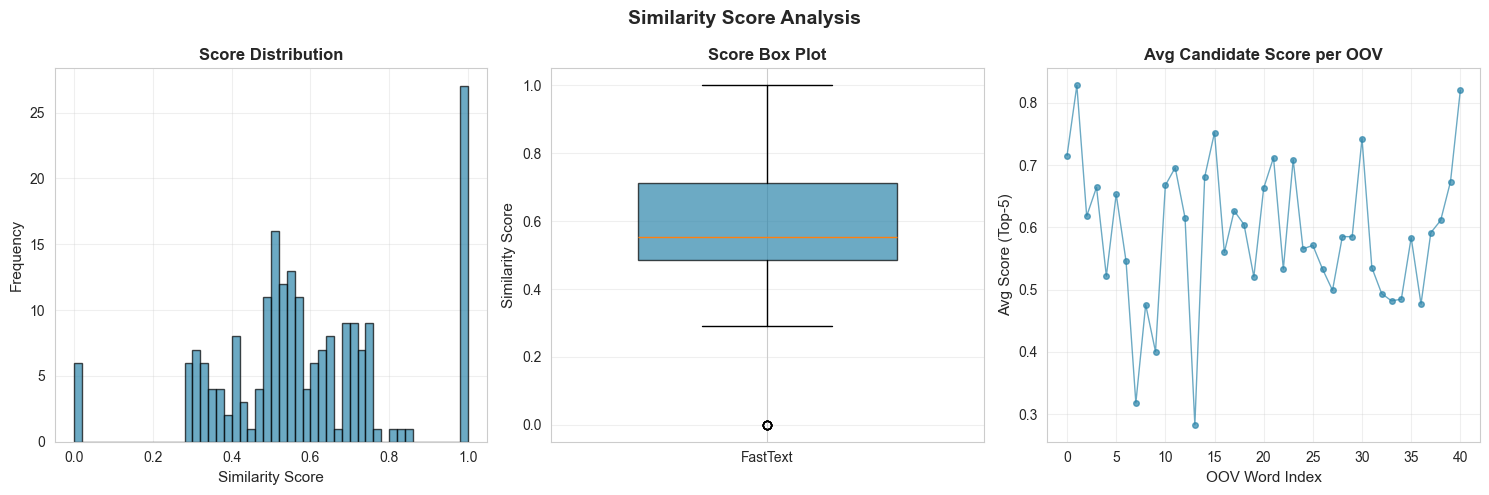

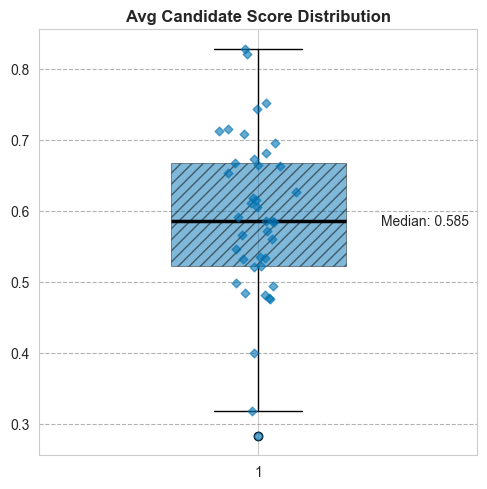

In [17]:
def plot_score_distribution_full(model: EmbeddingModel) -> None:
    """Three-panel overview: histogram, box plot, per-OOV average score."""
    scores_all, top_scores, avg_scores = [], [], []
    for candidates in model.oov_data.values():
        scores_all.extend([s for _, s in candidates])
        top_scores.append(candidates[0][1])
        avg_scores.append(np.mean([s for _, s in candidates[:5]]))

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    axes[0].hist(scores_all, bins=50, alpha=0.7, color='#2E86AB', edgecolor='black')
    axes[0].set_xlabel('Similarity Score', fontsize=11)
    axes[0].set_ylabel('Frequency', fontsize=11)
    axes[0].set_title('Score Distribution', fontsize=12, fontweight='bold')
    axes[0].grid(alpha=0.3)

    bp = axes[1].boxplot([scores_all], labels=[model.name], patch_artist=True, widths=0.6)
    bp['boxes'][0].set_facecolor('#2E86AB')
    bp['boxes'][0].set_alpha(0.7)
    axes[1].set_ylabel('Similarity Score', fontsize=11)
    axes[1].set_title('Score Box Plot', fontsize=12, fontweight='bold')
    axes[1].grid(axis='y', alpha=0.3)

    axes[2].plot(avg_scores, marker='o', linewidth=1, markersize=4, color='#2E86AB', alpha=0.7)
    axes[2].set_xlabel('OOV Word Index', fontsize=11)
    axes[2].set_ylabel('Avg Score (Top-5)', fontsize=11)
    axes[2].set_title('Avg Candidate Score per OOV', fontsize=12, fontweight='bold')
    axes[2].grid(alpha=0.3)

    plt.suptitle('Similarity Score Analysis', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()


def plot_score_distribution_detail(model: EmbeddingModel) -> None:
    """Single box plot with jittered points and median annotation."""
    avg_scores = [np.mean([s for _, s in cands[:5]]) for cands in model.oov_data.values()]

    BLUE = '#0072B2'
    fig, ax = plt.subplots(figsize=(5, 5))
    bp = ax.boxplot(avg_scores, patch_artist=True, widths=0.4,
                    medianprops=dict(color='black', linewidth=2.5))
    bp['boxes'][0].set_facecolor(BLUE)
    bp['boxes'][0].set_alpha(0.5)
    bp['boxes'][0].set_hatch('///')
    bp['boxes'][0].set_edgecolor('black')
    bp['boxes'][0].set_linewidth(0.6)

    x_jitter = np.random.normal(1, 0.04, size=len(avg_scores))
    ax.scatter(x_jitter, avg_scores, alpha=0.6, color=BLUE, s=20, zorder=3, marker='D')

    median_val = np.median(avg_scores)
    ax.text(1.28, median_val, f'Median: {median_val:.3f}', va='center', fontsize=10)
    ax.grid(axis='y', alpha=0.5, linestyle='--', color='#666666')
    ax.set_title('Avg Candidate Score Distribution', fontsize=12, fontweight='bold')
    plt.tight_layout()

    plt.savefig('oov_score_bp.png')
    plt.show()


plot_score_distribution_full(FT_model)
plot_score_distribution_detail(FT_model)